In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MinMaxScaler
from scipy.stats import percentileofscore

from sklearn.linear_model import LinearRegression

In [2]:
profit_loss = pd.read_csv(
    "exports/clean_profit_loss.csv"
)

balance_sheet = pd.read_csv(
    "exports/clean_balance_sheet.csv"
)

cash_flow = pd.read_csv(
    "exports/clean_cash_flow.csv"
)

analysis = pd.read_csv(
    "exports/clean_analysis.csv"
)

In [3]:
profitability = (
    profit_loss.groupby("company_id")
    .agg({
        "opm_percentage":"mean",
        "net_margin":"mean"
    })
)

In [4]:
balance_sheet["roe"] = (
    balance_sheet["reserves"] /
    (
        balance_sheet["equity_capital"] + 1
    )
) * 100

In [5]:
roe = (
    balance_sheet.groupby("company_id")
    ["roe"]
    .mean()
)

In [6]:
profitability = profitability.merge(
    roe,
    on="company_id",
    how="left"
)

In [7]:
profitability["opm_score"] = (
    profitability["opm_percentage"]
    .rank(pct=True)
)

profitability["margin_score"] = (
    profitability["net_margin"]
    .rank(pct=True)
)

profitability["roe_score"] = (
    profitability["roe"]
    .rank(pct=True)
)

In [8]:
profitability["profitability_score"] = (
    (
        profitability["opm_score"] +
        profitability["margin_score"] +
        profitability["roe_score"]
    ) / 3
) * 25

In [9]:
sales_growth = (
    profit_loss.groupby("company_id")
    ["sales"]
    .agg(["first","last"])
)

In [10]:
sales_growth["growth_3y"] = (
    (
        sales_growth["last"] /
        (sales_growth["first"] + 1)
    ) ** (1/3) - 1
) * 100

In [11]:
def growth_score(g):

    if g < 0:
        return 0

    elif g < 5:
        return 5

    elif g >= 20:
        return 20

    else:
        return (g / 20) * 20

In [12]:
sales_growth["growth_score"] = (
    sales_growth["growth_3y"]
    .apply(growth_score)
)

In [13]:
balance_sheet["de_ratio"] = (
    balance_sheet["borrowings"] /
    (
        balance_sheet["equity_capital"] +
        balance_sheet["reserves"] + 1
    )
)

In [14]:
debt = (
    balance_sheet.groupby("company_id")
    ["de_ratio"]
    .mean()
)

In [15]:
def debt_score(x):

    if x < 0.1:
        return 20

    elif x > 2:
        return 0

    else:
        return 20 * (1 - (x / 2))

In [16]:
debt = debt.to_frame()

debt["debt_score"] = (
    debt["de_ratio"]
    .apply(debt_score)
)

In [17]:
cash_merged = cash_flow.merge(
    profit_loss[
        [
            "company_id",
            "year",
            "net_profit"
        ]
    ],
    on=["company_id","year"],
    how="left"
)

In [18]:
cash_merged["cash_conversion"] = (
    cash_merged["operating_activity"] /
    (
        cash_merged["net_profit"] + 1
    )
)

In [19]:
cash_conversion = (
    cash_merged.groupby("company_id")
    ["cash_conversion"]
    .mean()
)

In [20]:
def cash_score(x):

    if x >= 1.2:
        return 15

    elif x <= 0:
        return 0

    else:
        return (x / 1.2) * 15

In [21]:
dividend = (
    profit_loss.groupby("company_id")
    ["dividend_payout"]
    .mean()
)

In [22]:
def dividend_score(x):

    if x >= 30:
        return 10

    elif x <= 0:
        return 0

    else:
        return (x / 30) * 10

In [23]:
dividend = dividend.to_frame()

dividend["dividend_score"] = (
    dividend["dividend_payout"]
    .apply(dividend_score)
)

In [24]:
trend_scores = []

In [25]:
for company in profit_loss["company_id"].unique():

    company_data = (
        profit_loss[
            profit_loss["company_id"] == company
        ]
        .sort_values("year")
        .tail(5)
    )

    if len(company_data) < 3:
        continue

    X = np.arange(len(company_data)).reshape(-1,1)

    y = company_data["sales"].values

    model = LinearRegression()

    model.fit(X,y)

    slope = model.coef_[0]

    if slope > 0:
        score = 10
    else:
        score = 0

    trend_scores.append({
        "company_id":company,
        "trend_score":score
    })

In [26]:
trend_df = pd.DataFrame(
    trend_scores
)

In [27]:
final_scores = profitability[
    ["profitability_score"]
].copy()

In [29]:
cash_conversion = cash_conversion.to_frame()

In [30]:
cash_conversion["cash_score"] = (
    cash_conversion["cash_conversion"]
    .apply(cash_score)
)

In [31]:
final_scores = final_scores.merge(
    cash_conversion[["cash_score"]],
    on="company_id"
)

In [34]:
dividend["dividend_score"] = (
    dividend["dividend_payout"]
    .apply(dividend_score)
)

In [35]:
final_scores = final_scores.merge(
    dividend[["dividend_score"]],
    on="company_id"
)

In [37]:
final_scores = final_scores.merge(
    trend_df,
    on="company_id"
)

In [38]:
final_scores.columns

Index(['company_id', 'profitability_score', 'growth_score', 'debt_score',
       'cash_score', 'dividend_score', 'trend_score'],
      dtype='object')

In [39]:
final_scores["health_score"] = (

    final_scores["profitability_score"] +

    final_scores["growth_score"] +

    final_scores["debt_score"] +

    final_scores["cash_score"] +

    final_scores["dividend_score"] +

    final_scores["trend_score"]

)

In [40]:
def label(score):

    if score >= 85:
        return "EXCELLENT"

    elif score >= 70:
        return "GOOD"

    elif score >= 50:
        return "AVERAGE"

    elif score >= 35:
        return "WEAK"

    else:
        return "POOR"

In [41]:
final_scores["label"] = (
    final_scores["health_score"]
    .apply(label)
)

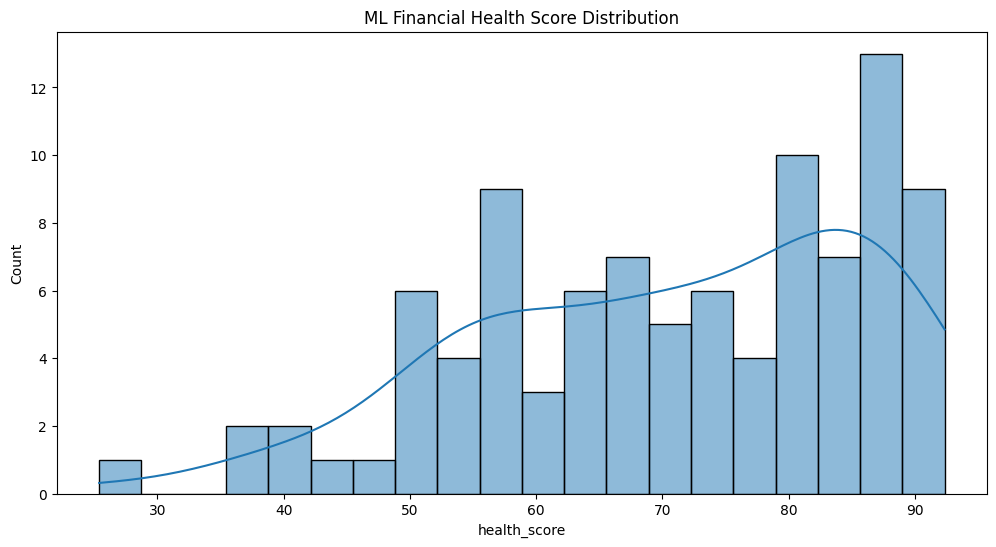

In [42]:
plt.figure(figsize=(12,6))

sns.histplot(
    final_scores["health_score"],
    bins=20,
    kde=True
)

plt.title(
    "ML Financial Health Score Distribution"
)

plt.show()

In [43]:
final_scores.sort_values(
    "health_score",
    ascending=False
).head(20)

,company_id,profitability_score,growth_score,debt_score,cash_score,dividend_score,trend_score,health_score,label
41,HINDUNILVR,19.107160,20.000000,20.000000,13.240622,10.000000,10,92.347782,EXCELLENT
79,SUNPHARMA,19.109101,20.000000,18.413248,15.000000,9.027778,10,91.550127,EXCELLENT
26,DIVISLAB,20.274892,20.000000,20.000000,11.168100,10.000000,10,91.442992,EXCELLENT
84,TCS,19.529204,20.000000,20.000000,11.825030,10.000000,10,91.354233,EXCELLENT
36,HCLTECH,17.002061,20.000000,20.000000,14.314730,10.000000,10,91.316791,EXCELLENT
24,COALINDIA,15.848639,20.000000,20.000000,14.867999,10.000000,10,90.716639,EXCELLENT
30,EICHERMOT,19.289494,20.000000,20.000000,13.520391,7.861111,10,90.670996,EXCELLENT
39,HEROMOTOCO,19.319762,16.628526,20.000000,13.742884,10.000000,10,89.691173,EXCELLENT
51,ITC,17.041040,20.000000,20.000000,12.091645,10.000000,10,89.132685,EXCELLENT
60,LTIM,16.773861,20.000000,20.000000,12.010149,10.000000,10,88.784010,EXCELLENT


In [44]:
final_scores.to_csv(
    "exports/ml_health_scores.csv",
    index=False
)